In [26]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv('train.csv', encoding='latin1')
df.head()

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,State,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales
0,1,CA-2017-152156,08/11/2017,11/11/2017,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,Kentucky,42420.0,South,FUR-BO-10001798,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.9600
1,2,CA-2017-152156,08/11/2017,11/11/2017,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,Kentucky,42420.0,South,FUR-CH-10000454,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.9400
2,3,CA-2017-138688,12/06/2017,16/06/2017,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,California,90036.0,West,OFF-LA-10000240,Office Supplies,Labels,Self-Adhesive Address Labels for Typewriters b...,14.6200
3,4,US-2016-108966,11/10/2016,18/10/2016,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,Florida,33311.0,South,FUR-TA-10000577,Furniture,Tables,Bretford CR4500 Series Slim Rectangular Table,957.5775
4,5,US-2016-108966,11/10/2016,18/10/2016,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,Florida,33311.0,South,OFF-ST-10000760,Office Supplies,Storage,Eldon Fold 'N Roll Cart System,22.3680


In [27]:
print("Shape:", df.shape)
print("\nData types:\n", df.dtypes)
print("\nNulls per column:\n", df.isnull().sum())

Shape: (9800, 18)

Data types:
 Row ID             int64
Order ID          object
Order Date        object
Ship Date         object
Ship Mode         object
Customer ID       object
Customer Name     object
Segment           object
Country           object
City              object
State             object
Postal Code      float64
Region            object
Product ID        object
Category          object
Sub-Category      object
Product Name      object
Sales            float64
dtype: object

Nulls per column:
 Row ID            0
Order ID          0
Order Date        0
Ship Date         0
Ship Mode         0
Customer ID       0
Customer Name     0
Segment           0
Country           0
City              0
State             0
Postal Code      11
Region            0
Product ID        0
Category          0
Sub-Category      0
Product Name      0
Sales             0
dtype: int64


In [28]:
df['Postal Code'] = df['Postal Code'].fillna(0)  # or drop these 11 rows, either is fine

In [29]:
df['Order Date'] = pd.to_datetime(df['Order Date'], format='%d/%m/%Y')
df['Ship Date'] = pd.to_datetime(df['Ship Date'], format='%d/%m/%Y')
print(df.dtypes[['Order Date', 'Ship Date']])

Order Date    datetime64[ns]
Ship Date     datetime64[ns]
dtype: object


In [30]:
print(df .columns.tolist())

['Row ID', 'Order ID', 'Order Date', 'Ship Date', 'Ship Mode', 'Customer ID', 'Customer Name', 'Segment', 'Country', 'City', 'State', 'Postal Code', 'Region', 'Product ID', 'Category', 'Sub-Category', 'Product Name', 'Sales']


In [31]:
df[['Sales']].describe()

,Sales
count,9800.000000
mean,230.769059
std,626.651875
min,0.444000
25%,17.248000
50%,54.490000
75%,210.605000
max,22638.480000


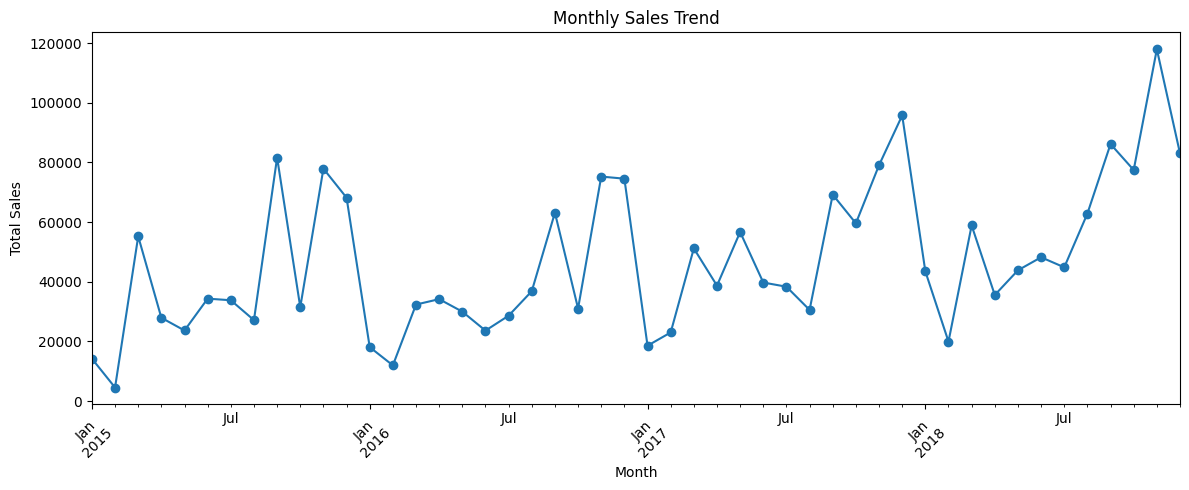

In [32]:
df['Order Month'] = df['Order Date'].dt.to_period('M')
monthly_sales = df.groupby('Order Month')['Sales'].sum()

plt.figure(figsize=(12,5))
monthly_sales.plot(kind='line', marker='o')
plt.title('Monthly Sales Trend')
plt.xlabel('Month')
plt.ylabel('Total Sales')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

Observation: Monthly sales show a strong overall upward trend from 2015 to 2018, growing from an average of 20,000-30,000/month in 2015 to consistently 60,000+ by 2018. Sales are volatile month-to-month, but a seasonal pattern is visible dips tend to occure early in each year, with peaks later in the year, suggesting stronger demand towards Q4 (possibly holiday-driven). The highest month is near the end of 2018 (100,000+), while the lowest is January 2015.

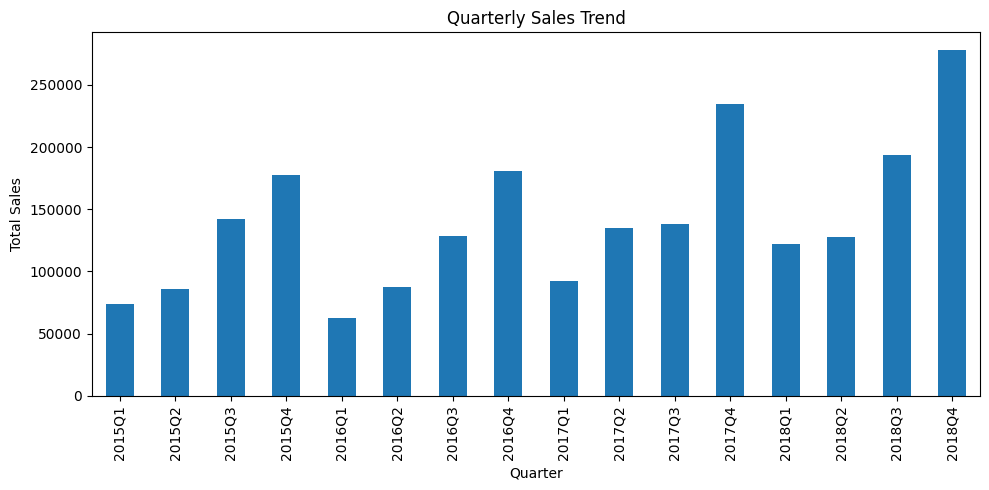

In [33]:
df['Order Quarter'] = df['Order Date'].dt.to_period('Q')
quarterly_sales = df.groupby('Order Quarter')['Sales'].sum()

plt.figure(figsize=(10,5))
quarterly_sales.plot(kind='bar')
plt.title('Quarterly Sales Trend')
plt.xlabel('Quarter')
plt.ylabel('Total Sales')
plt.tight_layout()
plt.show()

Observation: The quarterly view confirms a clear seasonal pattern Q4 is the strongest quarter every year, consistent with holiday shopping demand, while Q1 is typically the weakest as sales cool off after the holidays. Beyond the seasonality, there's a strong year-over-year growth trend: total sales roughly tripled from the smallest quarters in 2015 to the peak in 2018 Q4. This suggests the business is both growing steadily and highly dependent on Q4 performance.

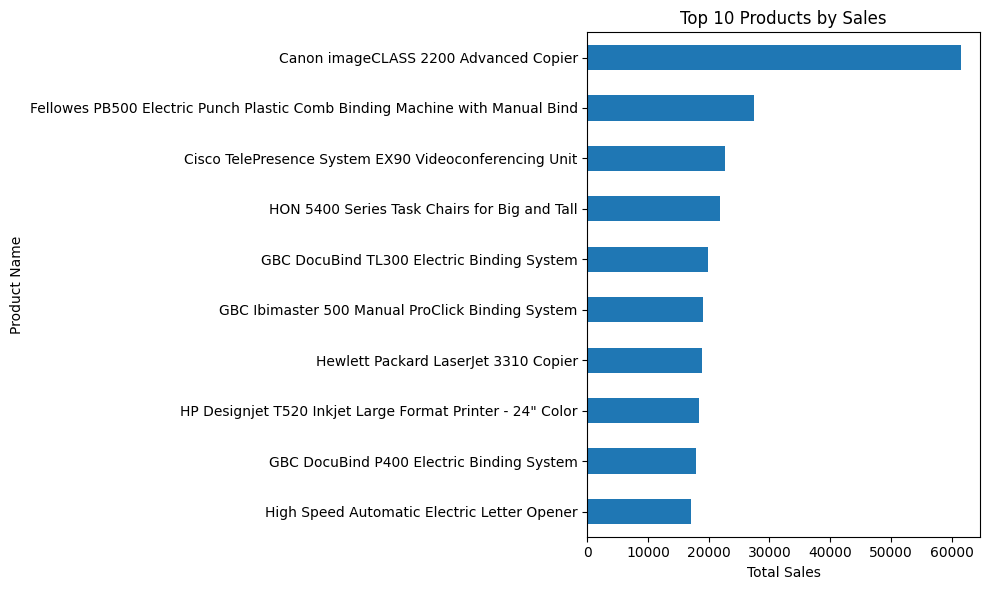

In [23]:
top_products = df.groupby('Product Name')['Sales'].sum().sort_values(ascending=False).head(10)

plt.figure(figsize=(10,6))
top_products.plot(kind='barh')
plt.title('Top 10 Products by Sales')
plt.xlabel('Total Sales')
plt.ylabel('Product Name')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

Observation: The Canon imageCLASS 2200 Advanced Copier is the clear top selling product, generating roughly double the sales of the next highest product. The rest of the top 10 is dominated by office equipment binding systems, printers, copiers, and office chairs suggesting the business's strongest revenue driver is high-ticket office machinery rather than everyday consumables.

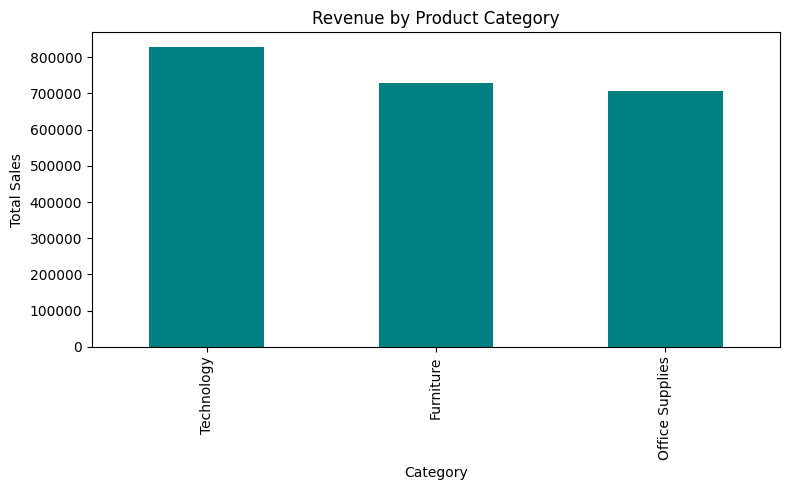

In [24]:
category_sales = df.groupby('Category')['Sales'].sum().sort_values(ascending=False)

plt.figure(figsize=(8,5))
category_sales.plot(kind='bar', color='teal')
plt.title('Revenue by Product Category')
plt.xlabel('Category')
plt.ylabel('Total Sales')
plt.tight_layout()
plt.show()

Observation: Revenue is fairly balanced across all three categories, with Technology leading (810,000), followed closely by Furniture (710,000) and Office Supplies (690,000). This aligns with the top products chart, where Technology items (copiers, printers) dominated individual product sales. Unlike many retailers, this business isn't overly reliant on one category all three contribute meaningfully to total revenue.

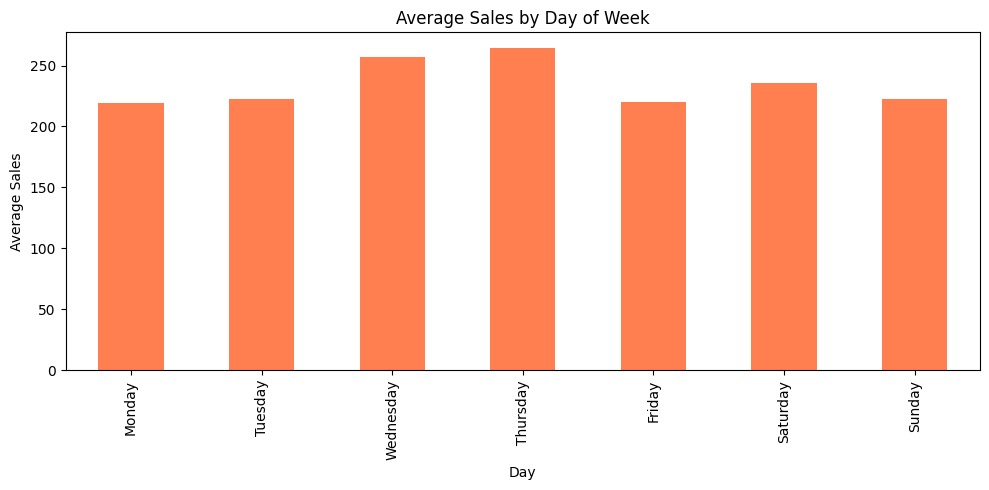

In [25]:
df['Order Day'] = df['Order Date'].dt.day_name()

day_sales = df.groupby('Order Day')['Sales'].mean().reindex(
    ['Monday','Tuesday','Wednesday','Thursday','Friday','Saturday','Sunday']
)

plt.figure(figsize=(10,5))
day_sales.plot(kind='bar', color='coral')
plt.title('Average Sales by Day of Week')
plt.xlabel('Day')
plt.ylabel('Average Sales')
plt.tight_layout()
plt.show()

Observation (Non-obvious insight): Contrary to typical retail patterns, weekday sales outperform weekends Wednesday and Thursday have the highest average order values (240), while Sunday is the lowest (180). This suggests the customer base is largely business/office buyers making purchases during the work week, rather than individual consumers shopping on weekends. This has practical implications: promotions or restocking efforts may be better timed mid-week rather than around weekend sales pushes.

## **Conclusion Key Insights & Recommendations**
Double down on Q4 preparation. Sales consistently peak in Q4 every year, with 2018Q4 hitting the highest point in the dataset. The business should ensure adequate stock, staffing, and marketing push heading into Q4 each year to fully capture this seasonal demand.
Technology is the growth engine protect and expand it. The Canon imageCLASS 2200 Advanced Copier alone drives outsized revenue, and Technology is the top category overall. Consider expanding the technology product line or running targeted promotions on high-performing tech SKUs.
Shift marketing/restocking effort to midweek. Since Wednesday and Thursday show the highest average sales atypical for retail this points to a business/B2B customer base. Promotions, sales calls, or inventory pushes timed for early-to-mid week are likely to outperform weekend-focused campaigns